In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("watson_healthcare_modified.csv")  

## Data Intergrity and Structure

In [3]:
print("Shape:", df.shape)


print("\nData Types:")
print(df.dtypes)

Shape: (1676, 35)

Data Types:
EmployeeID                   int64
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
Shift                   

In [4]:
null_counts = df.isnull().sum()
missing = null_counts[null_counts > 0]

if len(missing) > 0:
    print("\nMissing values found in:")
    print(missing)
else:
    print("\nNo missing values found.")


No missing values found.


## Static Feature Removal

In [5]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

for col in constant_cols:
    df.drop(columns=[col], inplace=True)
    print(f"{col} removed (constant value)")

if not constant_cols:
    print("No constant columns found.")

EmployeeCount removed (constant value)
Over18 removed (constant value)
StandardHours removed (constant value)


## Target Variable Analysis

Attrition Distribution (%):
Attrition
No     88.126492
Yes    11.873508
Name: proportion, dtype: float64


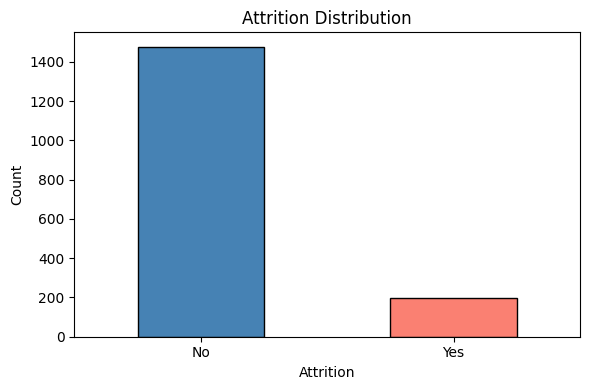

In [6]:
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print("Attrition Distribution (%):")
print(attrition_pct)

plt.figure(figsize=(6, 4))
df['Attrition'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Numerical Distributions Analysis


--- Age ---
  Mean:   36.87
  Median: 36.00
  Std:    9.13


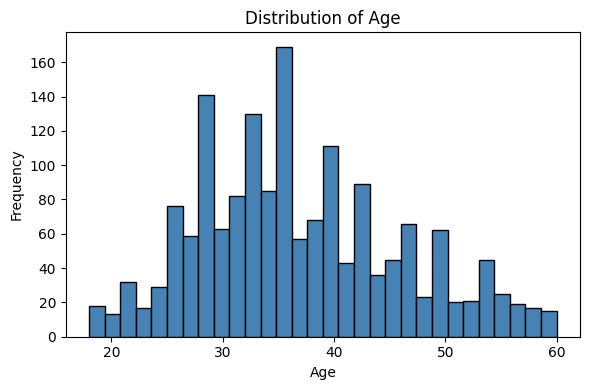


--- MonthlyIncome ---
  Mean:   6516.51
  Median: 4899.00
  Std:    4728.46


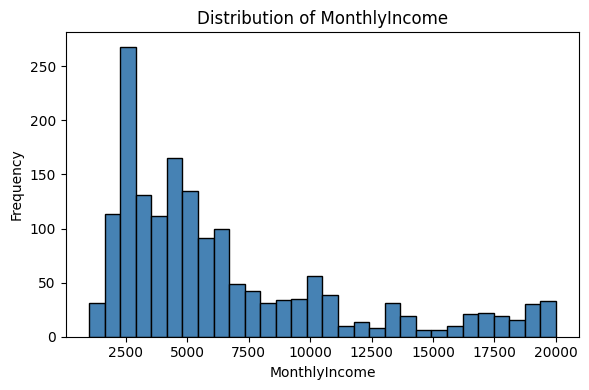


--- DistanceFromHome ---
  Mean:   9.22
  Median: 7.00
  Std:    8.16


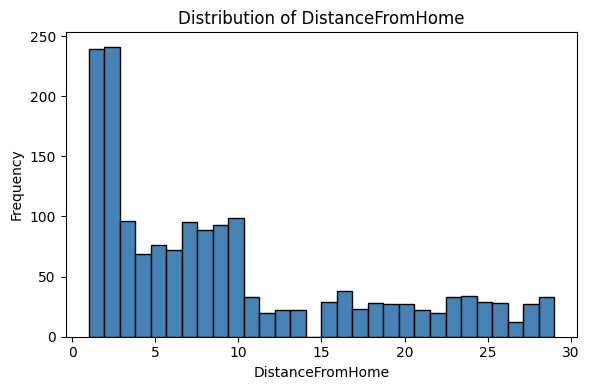


--- TotalWorkingYears ---
  Mean:   11.34
  Median: 10.00
  Std:    7.83


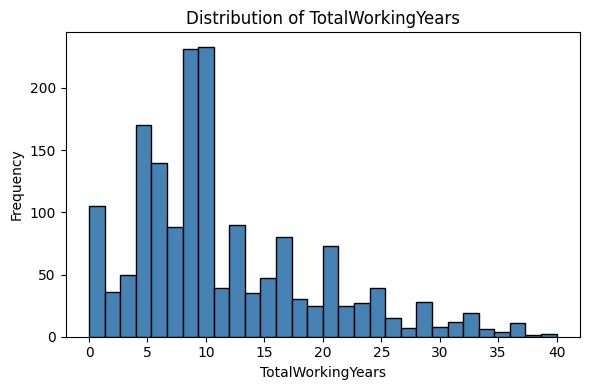

In [7]:
num_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears']

for col in num_cols:
    print(f"\n--- {col} ---")
    print(f"  Mean:   {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std:    {df[col].std():.2f}")

    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30, color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

## Categorical Distributions Analysis

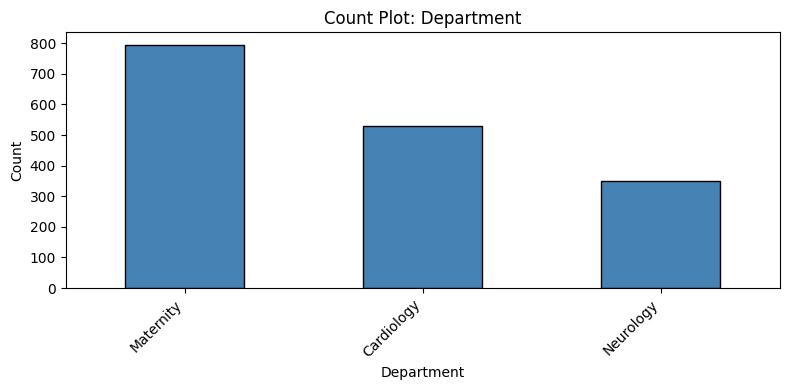

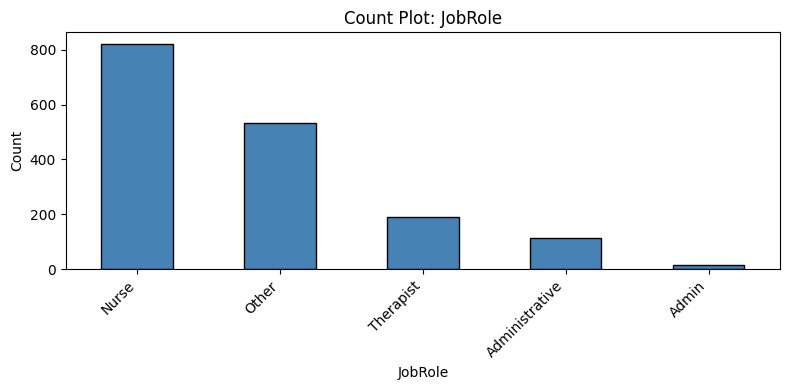

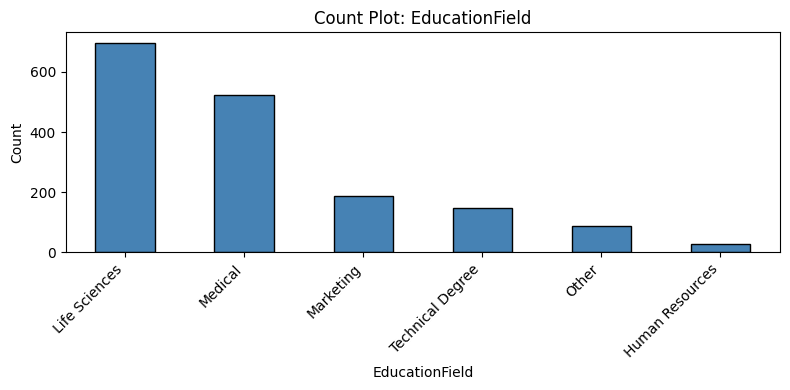

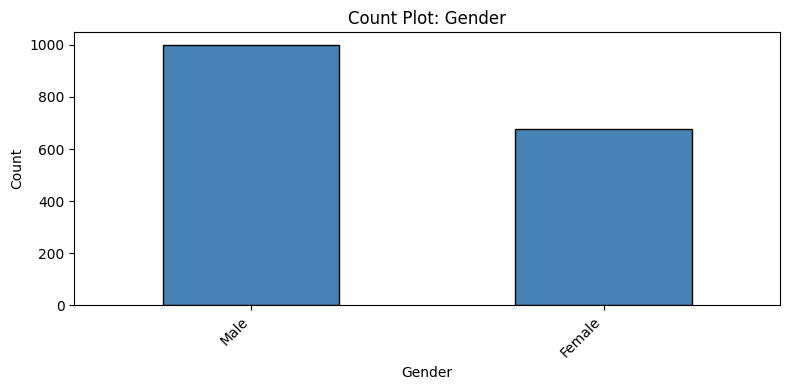

In [8]:
cat_cols = ['Department', 'JobRole', 'EducationField', 'Gender']

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Count Plot: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Categorical vs Attrition

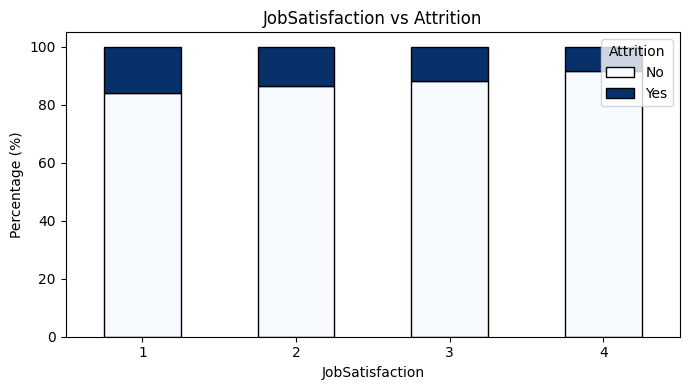

Correlation: Do lower JobSatisfaction scores lead to higher attrition?
Attrition           No    Yes
JobSatisfaction              
1                84.19  15.81
2                86.45  13.55
3                88.17  11.83
4                91.51   8.49 



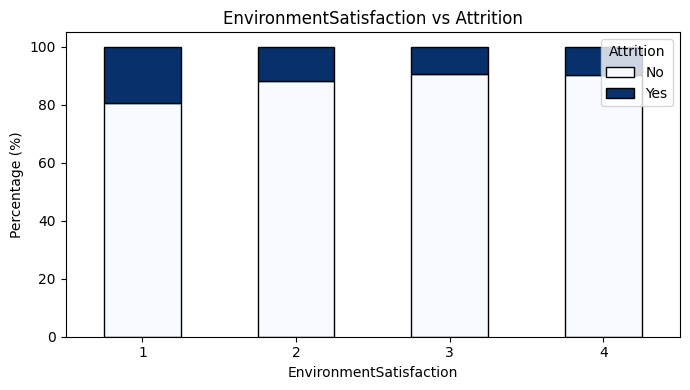

Correlation: Do lower EnvironmentSatisfaction scores lead to higher attrition?
Attrition                   No    Yes
EnvironmentSatisfaction              
1                        80.61  19.39
2                        88.34  11.66
3                        90.62   9.38
4                        90.35   9.65 



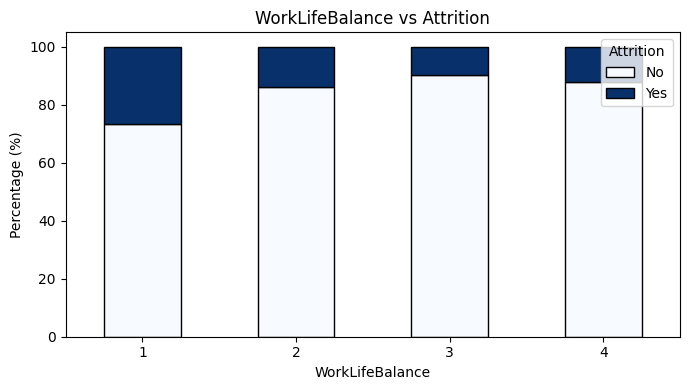

Correlation: Do lower WorkLifeBalance scores lead to higher attrition?
Attrition           No    Yes
WorkLifeBalance              
1                73.33  26.67
2                85.97  14.03
3                90.27   9.73
4                87.86  12.14 



In [12]:
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance']

for col in satisfaction_cols:
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100

    ct.plot(kind='bar', stacked=True, figsize=(7, 4), colormap='Blues', edgecolor='black')
    plt.title(f'{col} vs Attrition')
    plt.xlabel(col)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=0)
    plt.legend(title='Attrition', loc='upper right')
    plt.tight_layout()
    plt.show()

    print(f"Correlation: Do lower {col} scores lead to higher attrition?")
    print(ct.round(2), "\n")

## Numarical Variables vs Attrition

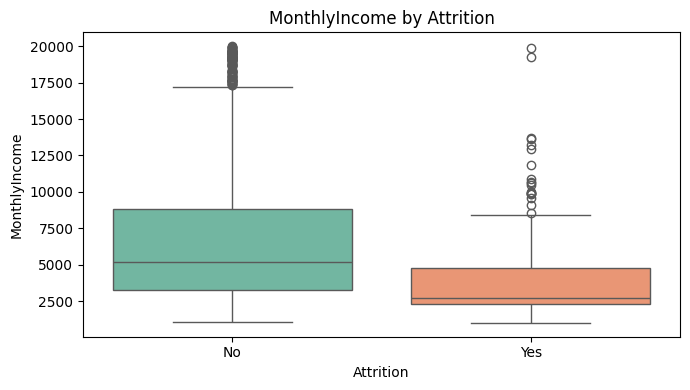

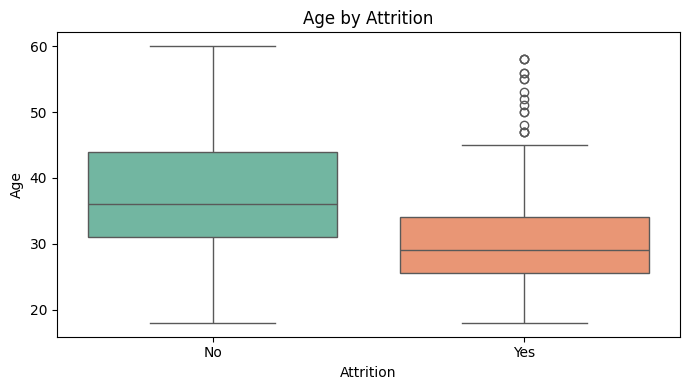

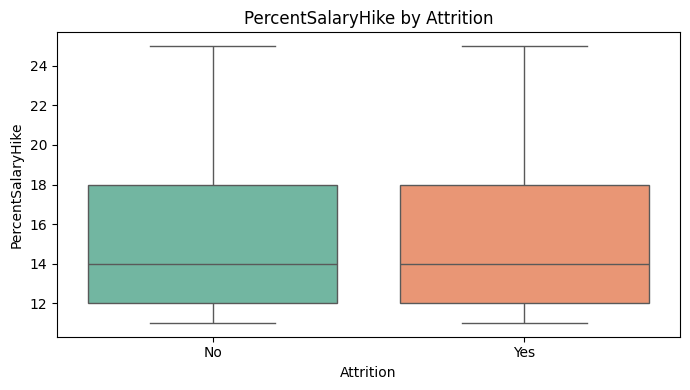

In [14]:
continuous_cols = ['MonthlyIncome', 'Age', 'PercentSalaryHike']

for col in continuous_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df,
        x='Attrition',
        y=col,
        hue='Attrition',  
        palette='Set2',
        legend=False       
    )
    plt.title(f'{col} by Attrition')
    plt.xlabel('Attrition')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Correlation Analysis

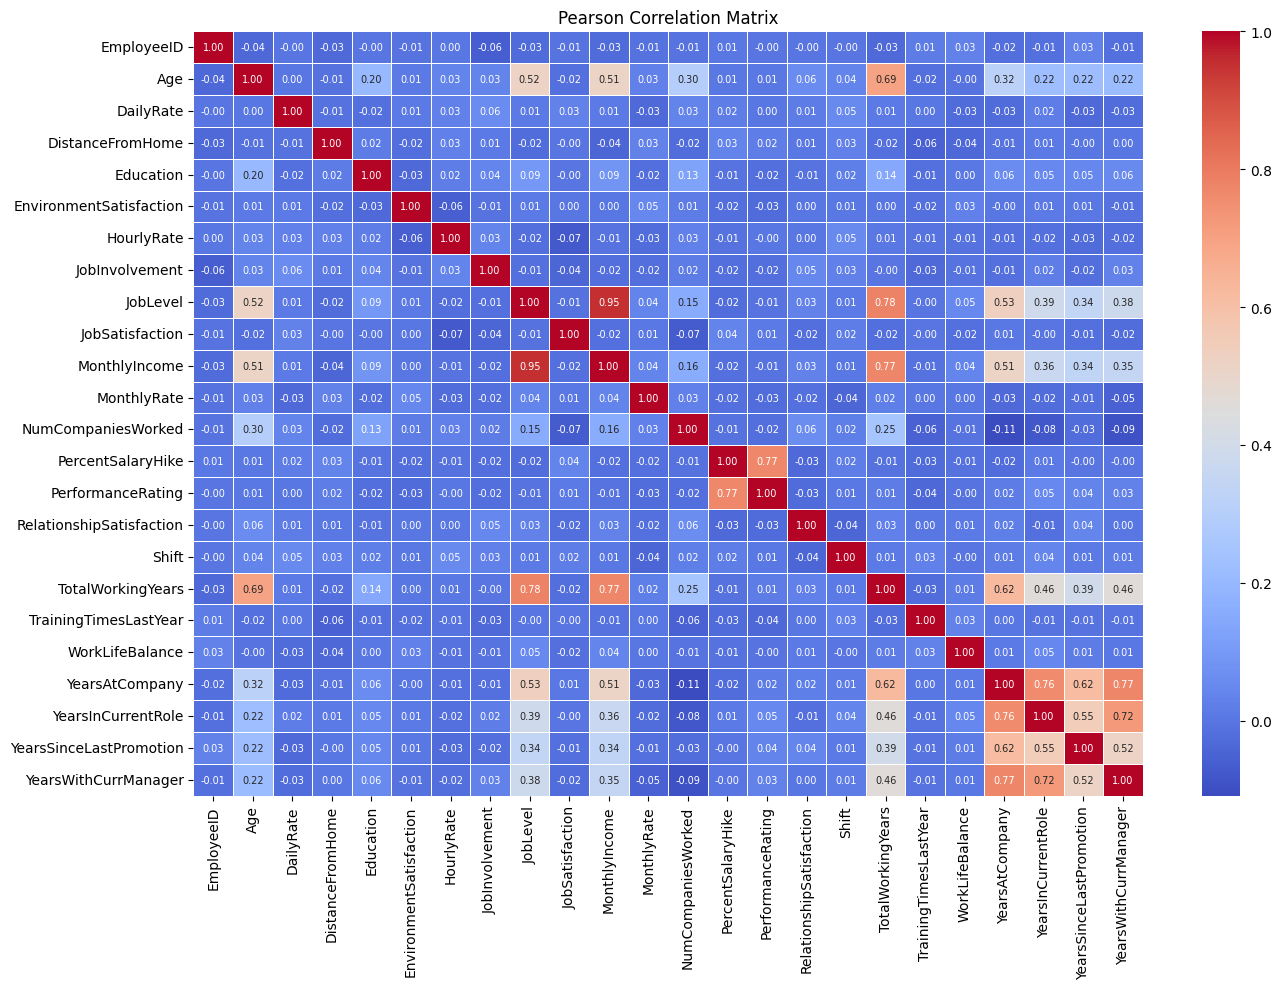

In [15]:
numerical_df = df.select_dtypes(include=[np.number])

corr_matrix = numerical_df.corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 7})
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

## Summary Findings

In [17]:
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

numerical_df2 = df.select_dtypes(include=[np.number])
target_corr = numerical_df2.corr()['Attrition_Binary'].drop('Attrition_Binary')
top_3 = target_corr.abs().sort_values(ascending=False).head(3)

print("Top 3 factors correlating with Attrition:")
print(top_3)

# Check class balance
attrition_counts = df['Attrition'].value_counts()
minority_pct = attrition_counts.min() / attrition_counts.sum() * 100
print(f"\nMinority class: {minority_pct:.1f}%")

if minority_pct < 30:
    print("Class imbalance detected")
else:
    print("Class distribution is reasonably balanced. Balancing may not be required.")

Top 3 factors correlating with Attrition:
Age                   0.239984
TotalWorkingYears     0.234182
YearsInCurrentRole    0.207891
Name: Attrition_Binary, dtype: float64

Minority class: 11.9%
Class imbalance detected


In [18]:
df.shape

(1676, 33)